<a href="https://www.kaggle.com/code/atrbyg24/predicting-optimal-fertilizers?scriptVersionId=244752263" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [32]:
train = pd.read_csv('/kaggle/input/playground-series-s5e6/train.csv',index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e6/test.csv')

In [33]:
train.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
id,,,,,,,,,
0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,27,69,65,Sandy,Millets,30,6,18,28-28
2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,35,58,43,Red,Paddy,37,2,16,DAP


In [34]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Temparature      750000 non-null  int64 
 1   Humidity         750000 non-null  int64 
 2   Moisture         750000 non-null  int64 
 3   Soil Type        750000 non-null  object
 4   Crop Type        750000 non-null  object
 5   Nitrogen         750000 non-null  int64 
 6   Potassium        750000 non-null  int64 
 7   Phosphorous      750000 non-null  int64 
 8   Fertilizer Name  750000 non-null  object
dtypes: int64(6), object(3)
memory usage: 57.2+ MB


In [35]:
train.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,31.503565,61.038912,45.184147,23.093808,9.478296,21.073227
std,4.025574,6.647695,11.794594,11.216125,5.765622,12.346831
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,55.000000,35.000000,13.000000,4.000000,10.000000
50%,32.000000,61.000000,45.000000,23.000000,9.000000,21.000000
75%,35.000000,67.000000,55.000000,33.000000,14.000000,32.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


In [36]:
cat_cols = ['Soil Type','Crop Type','Fertilizer Name']
num_cols = ['Temparature','Humidity','Moisture','Nitrogen','Potassium','Phosphorous']

In [37]:
for col in cat_cols:
    print(train[col].value_counts())

Soil Type
Sandy     156710
Black     150956
Clayey    148382
Red       148102
Loamy     145850
Name: count, dtype: int64
Crop Type
Paddy          85754
Pulses         78180
Cotton         69171
Tobacco        68000
Wheat          66628
Millets        65291
Barley         65045
Sugarcane      64269
Oil seeds      64184
Maize          62569
Ground Nuts    60909
Name: count, dtype: int64
Fertilizer Name
14-35-14    114436
10-26-26    113887
17-17-17    112453
28-28       111158
20-20       110889
DAP          94860
Urea         92317
Name: count, dtype: int64


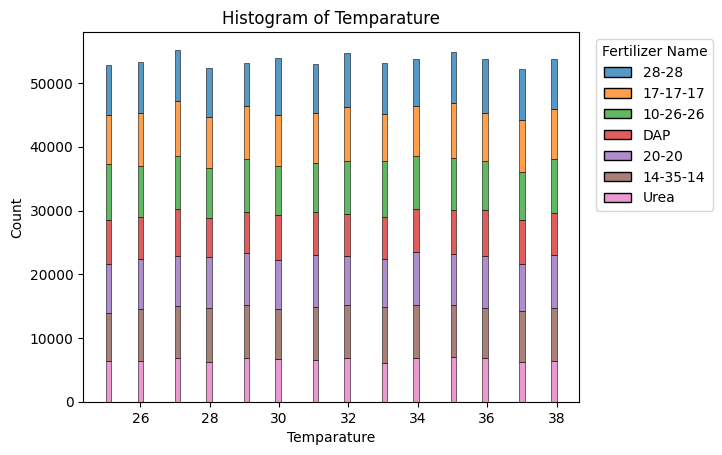

<Figure size 640x480 with 0 Axes>

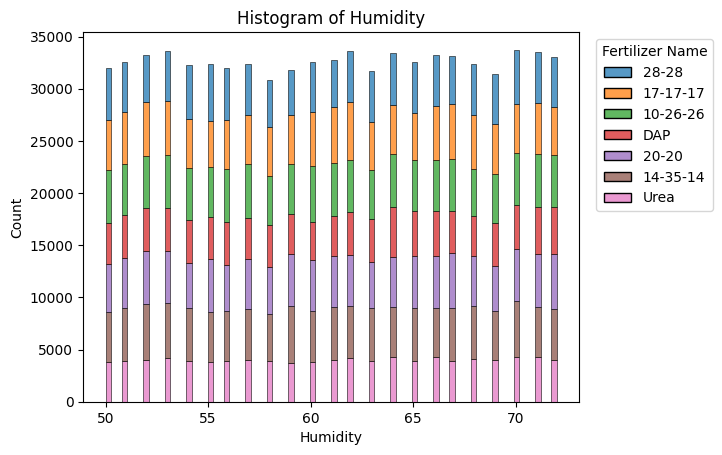

<Figure size 640x480 with 0 Axes>

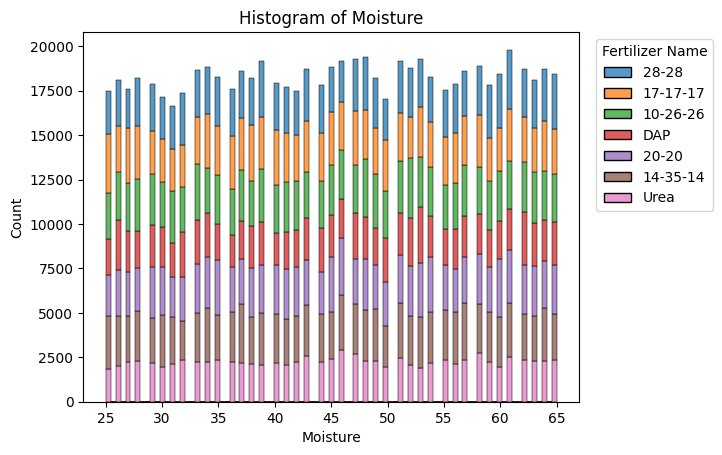

<Figure size 640x480 with 0 Axes>

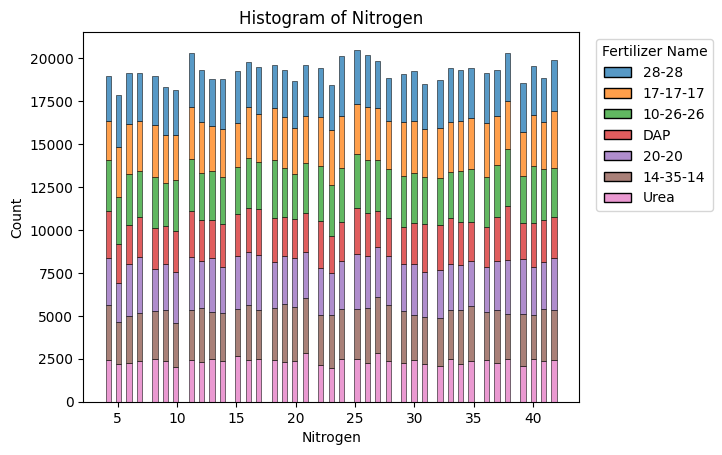

<Figure size 640x480 with 0 Axes>

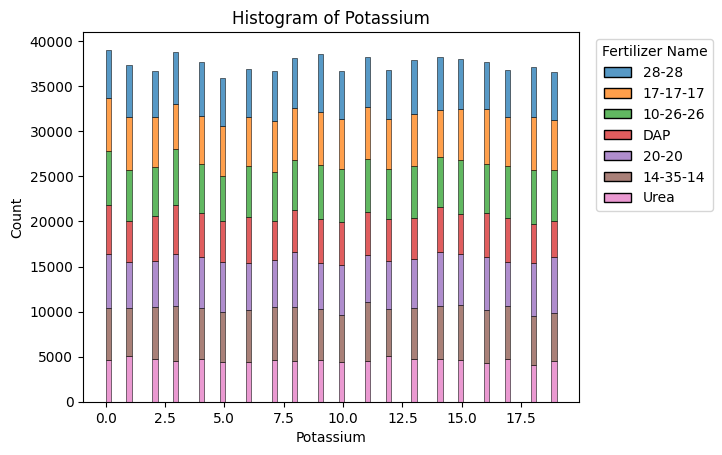

<Figure size 640x480 with 0 Axes>

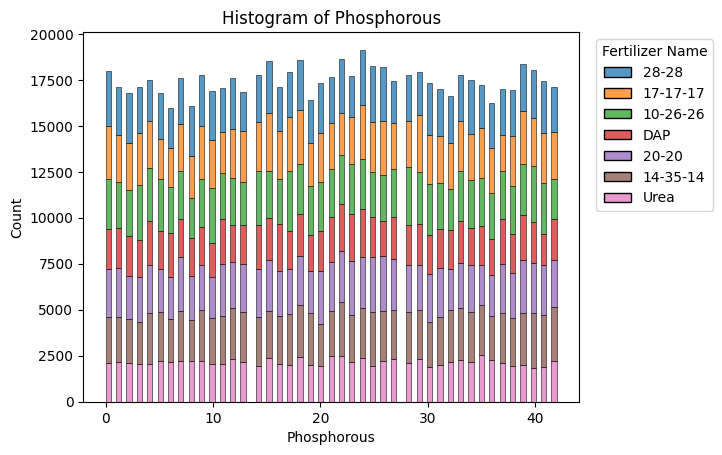

<Figure size 640x480 with 0 Axes>

In [38]:
for col in num_cols:
    plt.figure()
    ax = sns.histplot(data = train,x=col,hue='Fertilizer Name',multiple='stack')
    plt.title(f'Histogram of {col}')
    sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.show()
    plt.clf()

In [39]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train['Fertilizer Name'].copy())
X = train.drop('Fertilizer Name', axis=1).copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=17)

In [56]:
def ratio_feature(X):
    return X[:,[0]] / (X[:,[1]] + 1e-6)

def ratio_name(function_transformer,feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(ratio_feature,feature_names_out=ratio_name),
        StandardScaler()
    )

nominal_transformer = Pipeline(steps=[
    ('imputter',SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('NP_ratio',ratio_pipeline(),['Nitrogen','Phosphorous']),
    ('NK_ratio', ratio_pipeline(),['Nitrogen','Potassium']),
    ('PK_ratio', ratio_pipeline(),['Potassium','Phosphorous']),
    ('nominal', nominal_transformer, ['Soil Type', 'Crop Type'])
], remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(objective='multi:softprob',
                            eval_metric='mlogloss',
                            use_label_encoder=False,
                            random_state=42))
])

In [57]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('NP_ratio',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x795f81f38cc0>,
                                                                                       func=<function ratio_feature at 0x795ffef5a980>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [58]:
y_pred = model.predict(X_test)

In [59]:
probabilities = model.predict_proba(X_test)
print("\nPredicted probabilities on test set (first 5 samples):\n", probabilities[:5])


print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

classes = label_encoder.inverse_transform(model.named_steps['classifier'].classes_)

results = []
for i, prob_array in enumerate(probabilities[:5]): 
    sorted_indices = np.argsort(prob_array)[::-1]
    top3 = []
    for j in range(min(3, len(classes))):
        class_label = classes[sorted_indices[j]]
        top3.append(class_label)
    results.append(" ".join(top3))
print(results)


Predicted probabilities on test set (first 5 samples):
 [[0.12195782 0.12601672 0.18890235 0.13572465 0.1282844  0.1502646
  0.14884943]
 [0.13704586 0.19901446 0.1442838  0.17173935 0.1268572  0.10880145
  0.11225785]
 [0.13792486 0.20948692 0.16041118 0.14704107 0.13499236 0.11120537
  0.09893822]
 [0.13261104 0.14827612 0.15308699 0.11543491 0.15649733 0.15577756
  0.13831604]
 [0.12813736 0.09582786 0.3565883  0.15467438 0.08985884 0.08162636
  0.09328688]]

Model Accuracy: 0.17911333333333335

Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.21      0.20     23054
           1       0.18      0.24      0.20     22896
           2       0.19      0.23      0.21     22562
           3       0.17      0.18      0.18     22047
           4       0.17      0.20      0.18     22247
           5       0.18      0.10      0.13     18921
           6       0.18      0.06      0.09     18273

    accuracy                         

In [60]:
test_preds = model.predict_proba(test)
top_3_fertilizers = []
for i, pred in enumerate(test_preds):
    top_indices = np.argsort(pred)[::-1]  
    top3 = []
    for j in range(min(3, len(classes))):
        class_label = classes[sorted_indices[j]]
        top3.append(class_label)
    top_3_fertilizers.append(" ".join(top3))

submission = pd.DataFrame({'id': test['id'], 'Fertilizer Name': top_3_fertilizers})

submission.to_csv('submission.csv', index=False)

print("Submission file created successfully!")


Submission file created successfully!


In [61]:
submission.head(20)

,id,Fertilizer Name
0,750000,17-17-17 20-20 10-26-26
1,750001,17-17-17 20-20 10-26-26
2,750002,17-17-17 20-20 10-26-26
3,750003,17-17-17 20-20 10-26-26
4,750004,17-17-17 20-20 10-26-26
5,750005,17-17-17 20-20 10-26-26
6,750006,17-17-17 20-20 10-26-26
7,750007,17-17-17 20-20 10-26-26
8,750008,17-17-17 20-20 10-26-26
9,750009,17-17-17 20-20 10-26-26
